# 1. Data Load & Database Setup

In [80]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("../datasets/online_retail.csv", encoding='latin1')

# Convert Dates
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create SQLite Database connection
conn = sqlite3.connect("../datasets/sales.db")

# Push 
df.to_sql("sales", conn, if_exists="replace", index=False)

541909

# 2. Quick Validation

In [55]:
pd.read_sql("SELECT COUNT(*) FROM sales", conn)

,COUNT(*)
0,541909


# 3. Data Analysis

## 3.1. Data Understanding

### a) What does the dataset look like?

In [56]:
        pd.read_sql("""
        SELECT *
        FROM sales
        LIMIT 10
        """, conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


#### Insights
##### Dataset contains ~541k transactional records from a UK retail business. 
##### Each row represents a line item in an invoice.

### b) How big is the dataset?

In [57]:
        pd.read_sql("""
        SELECT COUNT(*) AS total_rows
        FROM sales;
        """, conn)

,total_rows
0,541909


## 3.2. Data Quality Checks

### a) Missing Customer Ids   

In [58]:
            pd.read_sql("""
            SELECT COUNT(*) 
            FROM sales
            WHERE CustomerID IS NULL
            """, conn)

,COUNT(*)
0,135080


### b) Negative Quantities (returns)

In [59]:
            pd.read_sql("""
            SELECT COUNT(*) 
            FROM sales
            WHERE Quantity < 0
            """, conn)

,COUNT(*)
0,10624


### c) Zero or Negative Price (Data issue Check)

In [60]:
        pd.read_sql("""
        SELECT COUNT(*) 
        FROM sales
        WHERE UnitPrice <= 0
        """, conn)

,COUNT(*)
0,2517


## 3.3. Business Overview

### a) Total Revenue

In [61]:
        pd.read_sql("""
        SELECT SUM(quantity * UnitPrice) AS total_revenue
        From sales
        """, conn)

,total_revenue
0,9747747.934


### b) Total number of orders

In [62]:
    pd.read_sql("""
    SELECT COUNT(DISTINCT InvoiceNo) as total_orders
    from sales;
    """, conn)

,total_orders
0,25900


### c) Average Order Value

In [63]:
    pd.read_sql("""
    SELECT 
        SUM(quantity * UnitPrice) * 1.0/ COUNT(DISTINCT InvoiceNo) AS avg_order_value
    from sales;
    """, conn)

,avg_order_value
0,376.360924


## 3.4. Customer Analysis

### a) Top 10 customer by revenue

In [64]:
    pd.read_sql("""
    SELECT
        CustomerID,
        SUM(quantity * UnitPrice) AS total_spend
    FROM sales
   WHERE CustomerID IS NOT NULL
    GROUP BY CustomerID
    ORDER BY total_spend DESC
    LIMIT 10;
    """, conn)
    

,CustomerID,total_spend
0,14646.0,279489.02
1,18102.0,256438.49
2,17450.0,187482.17
3,14911.0,132572.62
4,12415.0,123725.45
5,14156.0,113384.14
6,17511.0,88125.38
7,16684.0,65892.08
8,13694.0,62653.10
9,15311.0,59419.34


#### Insight:
##### A relatively small group of customers contributes a large share of revenue, suggesting customer concentration.

## 3.5. Product Analysis

### a) Best-selling products

In [65]:
    pd.read_sql("""
    SELECT
        description, 
        Sum(quantity) as units_sold
    FROM sales
    GROUP BY description
    Order by units_sold DESC
    LIMIT 10;
    """, conn)

,Description,units_sold
0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,53847
1,JUMBO BAG RED RETROSPOT,47363
2,ASSORTED COLOUR BIRD ORNAMENT,36381
3,POPCORN HOLDER,36334
4,PACK OF 72 RETROSPOT CAKE CASES,36039
5,WHITE HANGING HEART T-LIGHT HOLDER,35317
6,RABBIT NIGHT LIGHT,30680
7,MINI PAINT SET VINTAGE,26437
8,PACK OF 12 LONDON TISSUES,26315
9,PACK OF 60 PINK PAISLEY CAKE CASES,24753


### b) Highest revenue products

In [66]:
    pd.read_sql("""
    SELECT
      description,
      SUM(quantity * unitPrice) AS revenue
    FROM sales
    GROUP BY description
    ORDER BY revenue DESC
    LIMIT 10;
    """, conn)

,Description,revenue
0,DOTCOM POSTAGE,206245.48
1,REGENCY CAKESTAND 3 TIER,164762.19
2,WHITE HANGING HEART T-LIGHT HOLDER,99668.47
3,PARTY BUNTING,98302.98
4,JUMBO BAG RED RETROSPOT,92356.03
5,RABBIT NIGHT LIGHT,66756.59
6,POSTAGE,66230.64
7,PAPER CHAIN KIT 50'S CHRISTMAS,63791.94
8,ASSORTED COLOUR BIRD ORNAMENT,58959.73
9,CHILLI LIGHTS,53768.06


## 3.6. Revenue Trends

### a) Revenue by country

In [67]:
    pd.read_sql("""
    SELECT
        country,
        SUM(quantity * unitPrice) AS revenue
    FROM sales
    GROUP BY country
    ORDER BY revenue DESC
    LIMIT 10;
    """, conn)

,Country,revenue
0,United Kingdom,8187806.364
1,Netherlands,284661.540
2,EIRE,263276.820
3,Germany,221698.210
4,France,197403.900
5,Australia,137077.270
6,Switzerland,56385.350
7,Spain,54774.580
8,Belgium,40910.960
9,Sweden,36595.910


### b) Daily Revenue trend

In [68]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

pd.read_sql("""
SELECT
  DATE(InvoiceDate) AS day,
  SUM(Quantity * UnitPrice) AS revenue
FROM sales
GROUP BY day
ORDER BY day;
""", conn)

,day,revenue
0,2010-12-01,58635.56
1,2010-12-02,46207.28
2,2010-12-03,45620.46
3,2010-12-05,31383.95
4,2010-12-06,53860.18
...,...,...
300,2011-12-05,57751.32
301,2011-12-06,54228.37
302,2011-12-07,75076.22
303,2011-12-08,81417.78


### c) Monthly Revenue Trend

In [69]:
result = pd.read_sql("""
SELECT
  strftime('%Y-%m', InvoiceDate) AS month,
  SUM(Quantity * UnitPrice) AS monthly_revenue
FROM sales
GROUP BY month
ORDER BY month;
""", conn)

result

,month,monthly_revenue
0,2010-12,748957.020
1,2011-01,560000.260
2,2011-02,498062.650
3,2011-03,683267.080
4,2011-04,493207.121
5,2011-05,723333.510
6,2011-06,691123.120
7,2011-07,681300.111
8,2011-08,682680.510
9,2011-09,1019687.622


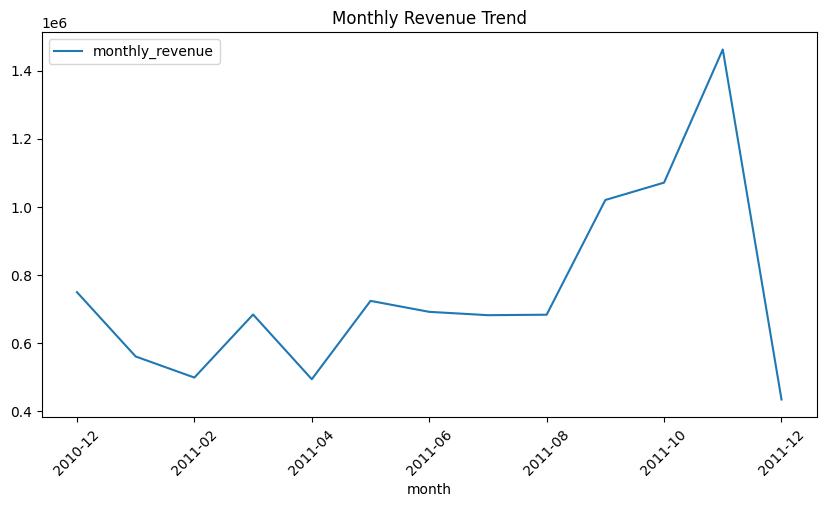

In [83]:
result = pd.read_sql("""
SELECT
  strftime('%Y-%m', InvoiceDate) AS month,
  SUM(Quantity * UnitPrice) AS monthly_revenue
FROM sales
GROUP BY month
ORDER BY month;
""", conn)

result



result.plot(
    x='month',
    y='monthly_revenue',
    kind='line',
    figsize=(10,5),
    title='Monthly Revenue Trend'
)

plt.xticks(rotation=45)
plt.show()

## 3.7. Advanced Insights (window functions + CTEs)

### a) Total Revenue

In [70]:
result = pd.read_sql("""
SELECT
  DATE(InvoiceDate) AS day,
  SUM(Quantity * UnitPrice) AS daily_revenue,
  SUM(SUM(Quantity * UnitPrice)) OVER (
    ORDER BY DATE(InvoiceDate)
  ) AS running_total
FROM sales
GROUP BY DATE(InvoiceDate)
ORDER BY day;
""", conn)

result

,day,daily_revenue,running_total
0,2010-12-01,58635.56,58635.560
1,2010-12-02,46207.28,104842.840
2,2010-12-03,45620.46,150463.300
3,2010-12-05,31383.95,181847.250
4,2010-12-06,53860.18,235707.430
...,...,...,...
300,2011-12-05,57751.32,9504894.034
301,2011-12-06,54228.37,9559122.404
302,2011-12-07,75076.22,9634198.624
303,2011-12-08,81417.78,9715616.404


#### Insight
##### This shows how revenue builds over time rather than only showing individual daily totals.

### b) Rank Customers

In [71]:
result = pd.read_sql("""
SELECT
  CustomerID,
  SUM(Quantity * UnitPrice) AS total_spend,
  RANK() OVER (
    ORDER BY SUM(Quantity * UnitPrice) DESC
  ) AS spend_rank
FROM sales
WHERE CustomerID IS NOT NULL
GROUP BY CustomerID
ORDER BY spend_rank;
""", conn)

result

,CustomerID,total_spend,spend_rank
0,14646.0,279489.02,1
1,18102.0,256438.49,2
2,17450.0,187482.17,3
3,14911.0,132572.62,4
4,12415.0,123725.45,5
...,...,...,...
4367,12503.0,-1126.00,4368
4368,17603.0,-1165.30,4369
4369,14213.0,-1192.20,4370
4370,15369.0,-1592.49,4371


#### Insight
##### Revenue is concentrated among the highest-spending customers, which may show where customer value is strongest.

## 3.8. Key Findings
##### - The dataset contains over 541k retail transaction rows. 
##### - A large number of rows have missing CustomerID values, limiting customer-level analysis
##### - Revenue is heavily concentrated among top customers.
##### - UK Sales dominate the dataset compared with other countries
##### - Returns and negative quantities should be treated carefully in future analysis

# 4. Conclusion
##### This project explored transactional retail data using SQL, Python, pandas and SQLite

##### Key areas analysed included:
###### - Customer Spending
###### - Product Performance
###### - Revenue Trends
###### - Data Quality Issues
###### - Advanced analytical Techniques using Window Functions

##### This analyis demonstrated how SQL can be used to answer real business questions and generate actionable insights from raw transactional data